In [32]:
from google.colab import files
uploaded = files.upload()

Saving description.txt to description (1).txt
Saving test_data.txt to test_data (1).txt
Saving test_data_solution.txt to test_data_solution (1).txt
Saving train_data.txt to train_data (1).txt


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# The dataset is pipe-separated: ID ||| TITLE ||| GENRE ||| DESCRIPTION
train_df = pd.read_csv('train_data.txt', sep=' ::: ', engine='python',
                       names=['ID', 'Title', 'Genre', 'Description'])

test_df = pd.read_csv('test_data.txt', sep=' ::: ', engine='python',
                       names=['ID', 'Title', 'Description'])

test_solution_df = pd.read_csv('test_data_solution.txt', sep=' ::: ', engine='python',
                       names=['ID', 'Title', 'Genre', 'Description'])

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print(train_df.head())

Train Shape: (54214, 4)
Test Shape: (54200, 3)
   ID                             Title     Genre  \
0   1      Oscar et la dame rose (2009)     drama   
1   2                      Cupid (1997)  thriller   
2   3  Young, Wild and Wonderful (1980)     adult   
3   4             The Secret Sin (1915)     drama   
4   5            The Unrecovered (2007)     drama   

                                         Description  
0  Listening in to a conversation between his doc...  
1  A brother and sister with a past incestuous re...  
2  As the bus empties the students for their fiel...  
3  To help their unemployed father make ends meet...  
4  The film's title refers not only to the un-rec...  


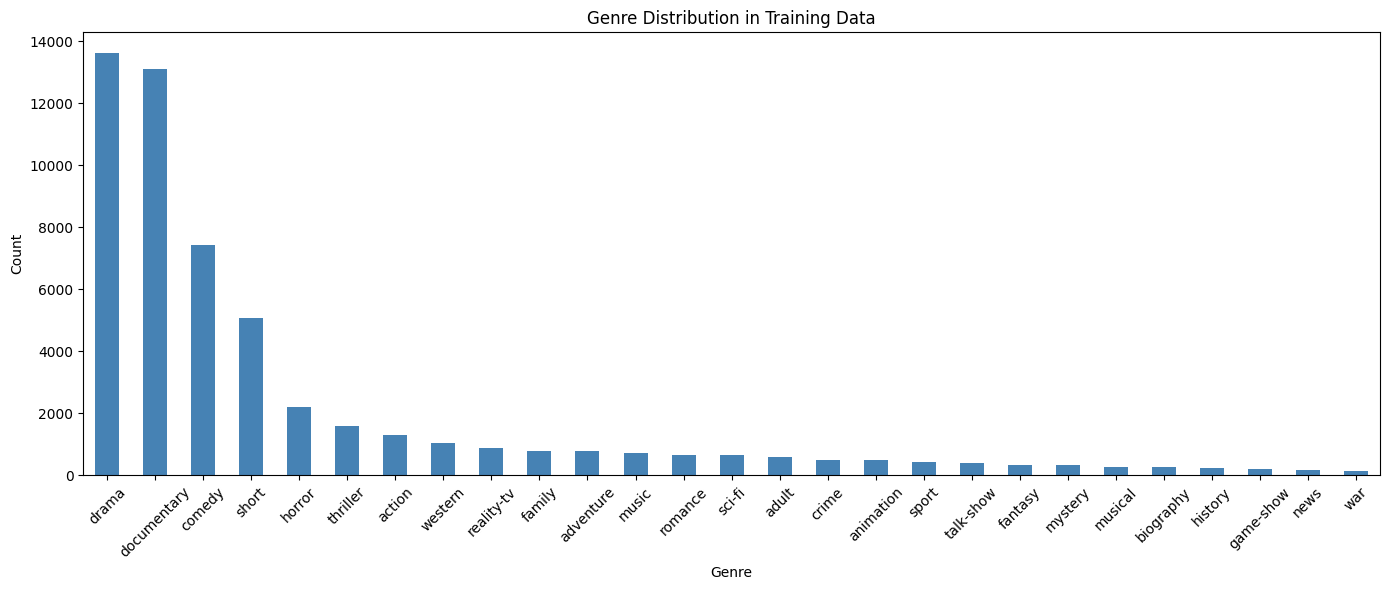

In [34]:
plt.figure(figsize=(14, 6))
train_df['Genre'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Genre Distribution in Training Data')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
import re
from sklearn.preprocessing import LabelEncoder

def clean_text(text):
    text = text.lower()                          # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)        # Remove special chars/numbers
    text = re.sub(r'\s+', ' ', text).strip()    # Remove extra whitespace
    return text

# Apply cleaning
train_df['Cleaned'] = train_df['Description'].apply(clean_text)
test_df['Cleaned']  = test_df['Description'].apply(clean_text)

# Encode labels
le = LabelEncoder()
train_df['Genre_Encoded'] = le.fit_transform(train_df['Genre'])

print("Classes:", le.classes_)

Classes: ['action' 'adult' 'adventure' 'animation' 'biography' 'comedy' 'crime'
 'documentary' 'drama' 'family' 'fantasy' 'game-show' 'history' 'horror'
 'music' 'musical' 'mystery' 'news' 'reality-tv' 'romance' 'sci-fi'
 'short' 'sport' 'talk-show' 'thriller' 'war' 'western']


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))

X_train = tfidf.fit_transform(train_df['Cleaned'])
y_train = train_df['Genre_Encoded']

X_test = tfidf.transform(test_df['Cleaned'])
y_test = le.transform(test_solution_df['Genre'])

print("X_train shape:", X_train.shape)

X_train shape: (54214, 10000)


In [37]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Naive Bayes":        MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=5, solver='lbfgs', multi_class='auto'),
    "Linear SVM":         LinearSVC(C=1.0, max_iter=1000)
            }

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{'='*40}")
    print(f"Model: {name}  |  Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=le.classes_))


Model: Naive Bayes  |  Accuracy: 0.5258
              precision    recall  f1-score   support

      action       0.62      0.08      0.14      1314
       adult       0.53      0.06      0.10       590
   adventure       0.77      0.09      0.16       775
   animation       0.00      0.00      0.00       498
   biography       0.00      0.00      0.00       264
      comedy       0.52      0.44      0.48      7446
       crime       0.00      0.00      0.00       505
 documentary       0.57      0.88      0.69     13096
       drama       0.46      0.84      0.60     13612
      family       0.00      0.00      0.00       783
     fantasy       0.00      0.00      0.00       322
   game-show       0.98      0.21      0.35       193
     history       0.00      0.00      0.00       243
      horror       0.72      0.33      0.45      2204
       music       0.90      0.05      0.09       731
     musical       0.00      0.00      0.00       276
     mystery       0.00      0.00      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/l


Model: Logistic Regression  |  Accuracy: 0.5847
              precision    recall  f1-score   support

      action       0.44      0.34      0.39      1314
       adult       0.62      0.34      0.44       590
   adventure       0.49      0.21      0.29       775
   animation       0.44      0.13      0.21       498
   biography       0.00      0.00      0.00       264
      comedy       0.53      0.59      0.56      7446
       crime       0.23      0.06      0.10       505
 documentary       0.70      0.82      0.75     13096
       drama       0.57      0.73      0.64     13612
      family       0.41      0.15      0.22       783
     fantasy       0.37      0.09      0.15       322
   game-show       0.91      0.58      0.70       193
     history       0.21      0.02      0.03       243
      horror       0.64      0.60      0.62      2204
       music       0.64      0.49      0.55       731
     musical       0.27      0.05      0.09       276
     mystery       0.30      0.0

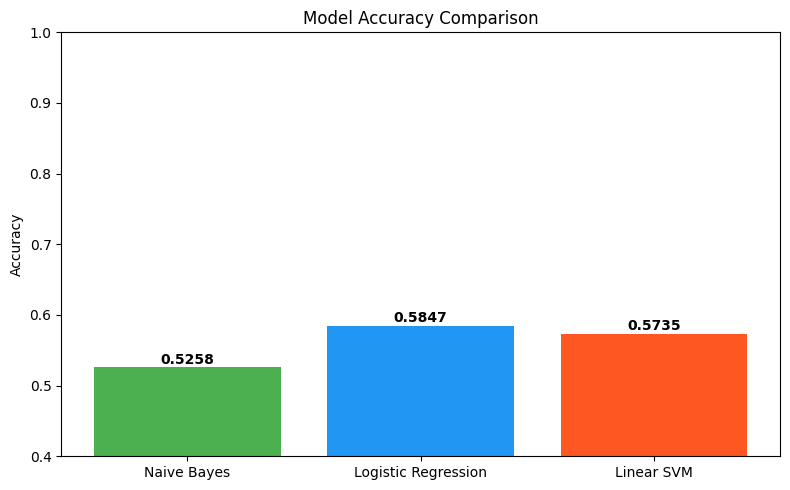

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['#4CAF50', '#2196F3', '#FF5722'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.4, 1.0)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

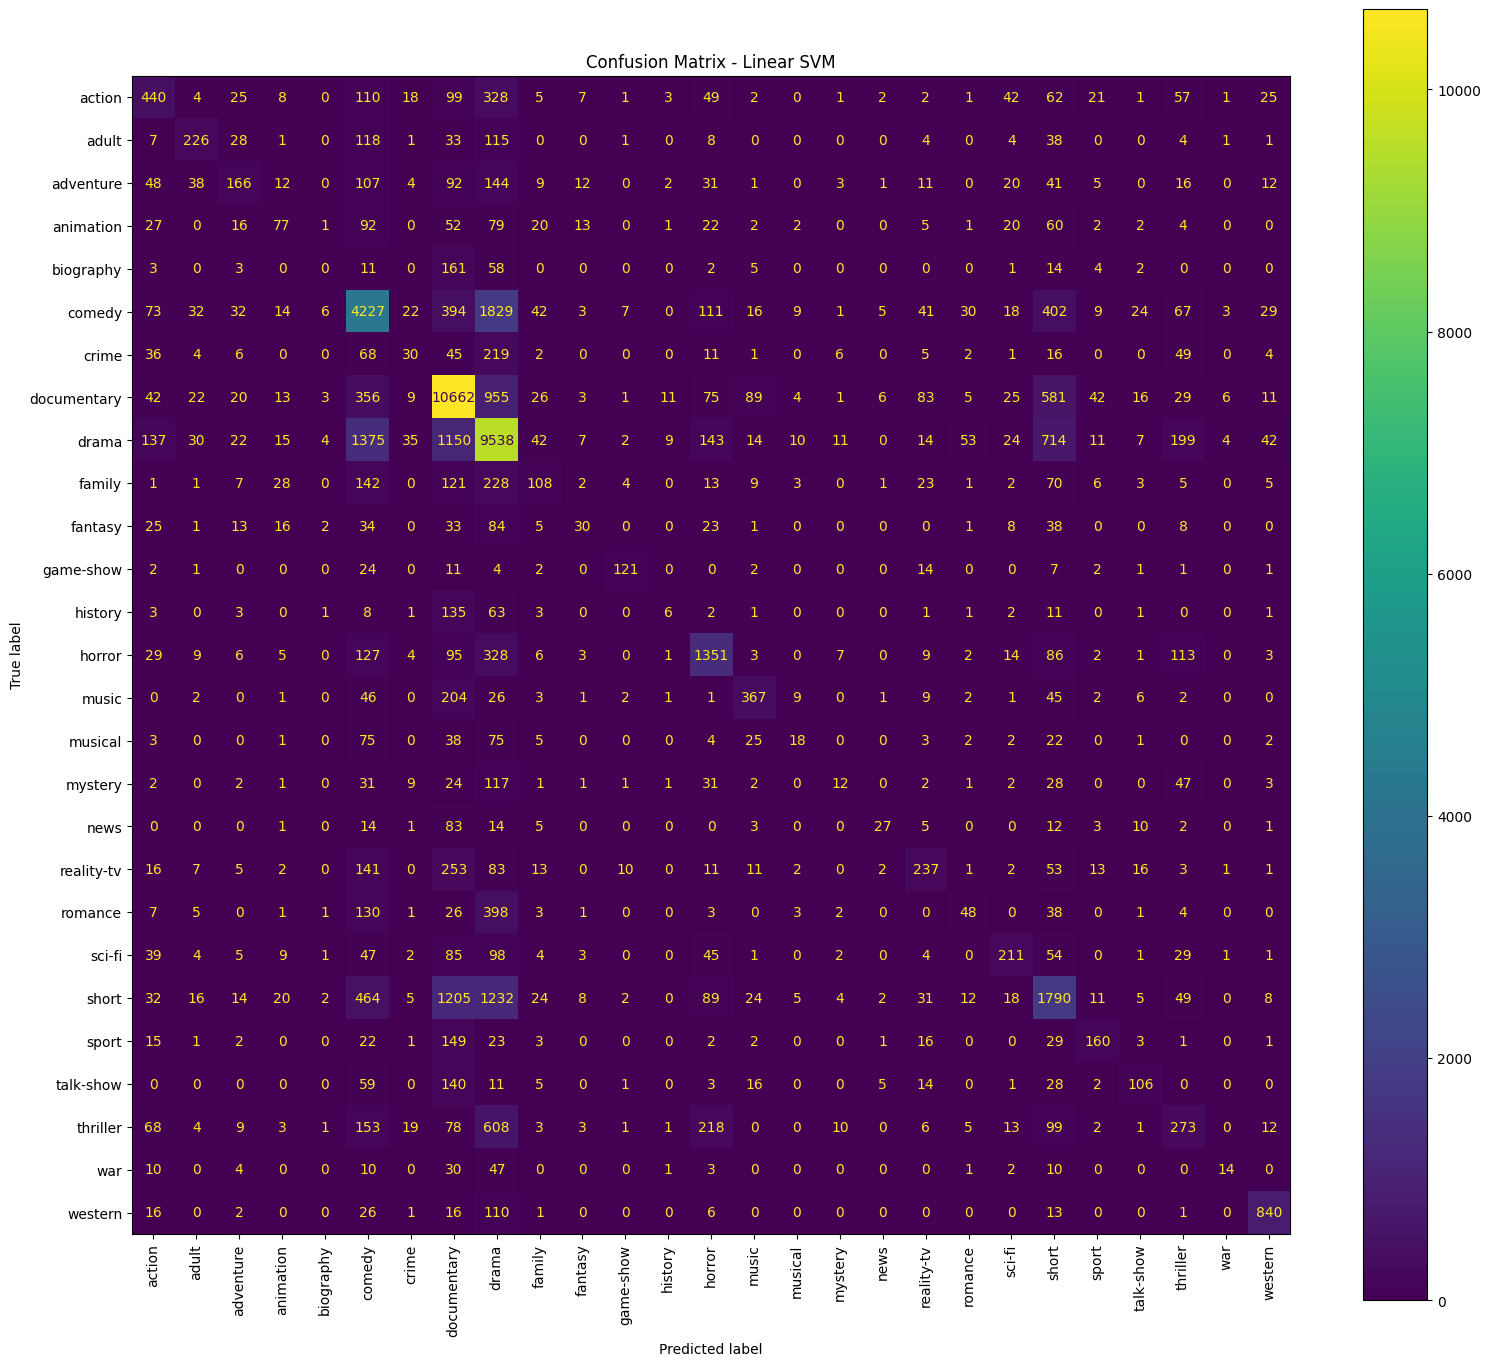

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = models["Linear SVM"]
preds_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(16, 14))
disp.plot(ax=ax, xticks_rotation=90, colorbar=True)
plt.title("Confusion Matrix - Linear SVM")
plt.tight_layout()
plt.show()

In [41]:
def predict_genre(description, model=best_model, vectorizer=tfidf, encoder=le):
    cleaned    = clean_text(description)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)
    genre      = encoder.inverse_transform(prediction)
    return genre[0]

# 🎯 Test it!
examples = [
    "A young wizard discovers his magical powers and enrolls in a school for witchcraft and wizardry.",
    "Two detectives chase a serial killer who targets victims based on the seven deadly sins.",
    "A romantic couple falls in love during a summer vacation in Paris.",
    "Aliens invade Earth and humanity must band together to fight back."
]

print("🎬 Genre Predictions:")
print("-" * 60)
for desc in examples:
    genre = predict_genre(desc)
    print(f"📝 {desc[:60]}...")
    print(f"🎯 Predicted Genre: {genre.upper()}\n")

🎬 Genre Predictions:
------------------------------------------------------------
📝 A young wizard discovers his magical powers and enrolls in a...
🎯 Predicted Genre: ANIMATION

📝 Two detectives chase a serial killer who targets victims bas...
🎯 Predicted Genre: THRILLER

📝 A romantic couple falls in love during a summer vacation in ...
🎯 Predicted Genre: ROMANCE

📝 Aliens invade Earth and humanity must band together to fight...
🎯 Predicted Genre: SCI-FI

